In [1]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\amish\OneDrive\Desktop\portfolio\fintech-customer-churn-retention\data\raw\Bank Customer Churn Prediction.csv"
)

In [2]:
df["churn"].value_counts()

churn
0    7963
1    2037
Name: count, dtype: int64

In [3]:

#Let's visualize it

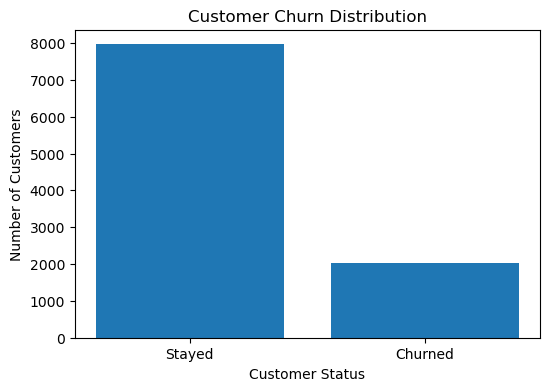

In [4]:
import matplotlib.pyplot as plt

churn_counts = df["churn"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(["Stayed", "Churned"], churn_counts.values)
plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.show()

In [5]:
#Churn Rate by Country

In [6]:
country_churn = (
    df.groupby("country")["churn"]
      .mean()
      .mul(100)
      .reset_index(name="churn_rate")
)

country_churn

,country,churn_rate
0,France,16.154767
1,Germany,32.443204
2,Spain,16.673395


In [7]:
df.groupby("country")["churn"].mean()

country
France     0.161548
Germany    0.324432
Spain      0.166734
Name: churn, dtype: float64

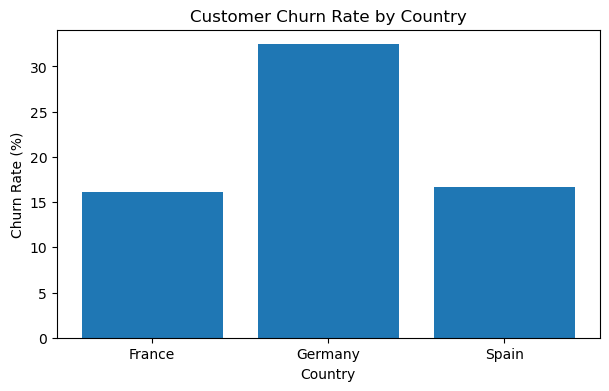

In [8]:
plt.figure(figsize=(7, 4))

plt.bar(
    country_churn["country"],
    country_churn["churn_rate"]
)

plt.title("Customer Churn Rate by Country")
plt.xlabel("Country")
plt.ylabel("Churn Rate (%)")
plt.show()

In [9]:
#Calculate churn rate by gender

In [10]:
churn_by_gender = df.groupby('gender')['churn'].mean()

print(churn_by_gender)

gender
Female    0.250715
Male      0.164559
Name: churn, dtype: float64


In [11]:
#Churn Rate by Age

In [12]:
df['age'].describe()

count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: age, dtype: float64

In [13]:
bins = [17, 25, 35, 45, 55, 100]

labels = ['18-25', '26-35', '36-45', '46-55', '56+']

df['age_group'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels
)

df['age_group'].value_counts().sort_index()

age_group
18-25     611
26-35    3542
36-45    3736
46-55    1311
56+       800
Name: count, dtype: int64

In [14]:
#churn rate

In [15]:
churn_by_age = df.groupby('age_group', observed=True)['churn'].mean()

print(churn_by_age)

age_group
18-25    0.075286
26-35    0.084980
36-45    0.196199
46-55    0.505721
56+      0.367500
Name: churn, dtype: float64


Churn Rate by Credit Score

In [16]:
df['credit_score'].describe()

count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: credit_score, dtype: float64

In [17]:
bins = [299, 579, 669, 739, 799, 850]

labels = ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']

df['credit_score_group'] = pd.cut(
    df['credit_score'],
    bins=bins,
    labels=labels
)

df['credit_score_group'].value_counts().sort_index()

credit_score_group
Poor         2362
Fair         3331
Good         2428
Very Good    1224
Excellent     655
Name: count, dtype: int64

In [18]:
churn_by_credit = (
    df.groupby('credit_score_group', observed=True)['churn']
      .mean()
)

print(churn_by_credit)

credit_score_group
Poor         0.220152
Fair         0.205644
Good         0.186161
Very Good    0.205882
Excellent    0.195420
Name: churn, dtype: float64


In [19]:
df['tenure'].describe()

count    10000.000000
mean         5.012800
std          2.892174
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: tenure, dtype: float64

In [20]:
df['tenure'].value_counts().sort_index()

tenure
0      413
1     1035
2     1048
3     1009
4      989
5     1012
6      967
7     1028
8     1025
9      984
10     490
Name: count, dtype: int64

In [21]:
churn_by_tenure = df.groupby('tenure')['churn'].mean()

print(churn_by_tenure)

tenure
0     0.230024
1     0.224155
2     0.191794
3     0.211100
4     0.205258
5     0.206522
6     0.202689
7     0.172179
8     0.192195
9     0.216463
10    0.206122
Name: churn, dtype: float64


In [22]:
#Churn Rate by Balance

In [23]:
df['balance'].describe()

count     10000.000000
mean      76485.889288
std       62397.405202
min           0.000000
25%           0.000000
50%       97198.540000
75%      127644.240000
max      250898.090000
Name: balance, dtype: float64

In [24]:
(df['balance'] == 0).sum()

np.int64(3617)

In [25]:
(df['balance'] == 0).mean() * 100

np.float64(36.17)

In [26]:
balance_churn = df.groupby(df['balance'] == 0)['churn'].mean()
balance_churn

balance
False    0.240796
True     0.138236
Name: churn, dtype: float64

Customers with a non-zero account balance show substantially higher churn than customers with zero balance. This suggests account balance may be associated with retention behavior, although the relationship should not be interpreted as causal.

visualization

<Axes: title={'center': 'Churn Rate by Balance Status'}, xlabel='Has Balance', ylabel='Churn Rate'>

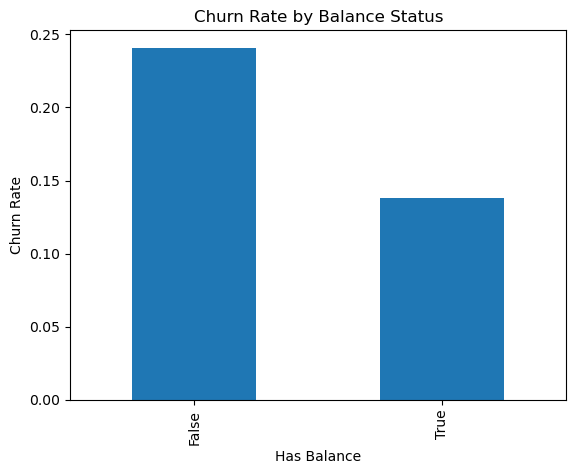

In [27]:
balance_churn.plot(
    kind='bar',
    title='Churn Rate by Balance Status',
    xlabel='Has Balance',
    ylabel='Churn Rate'
)

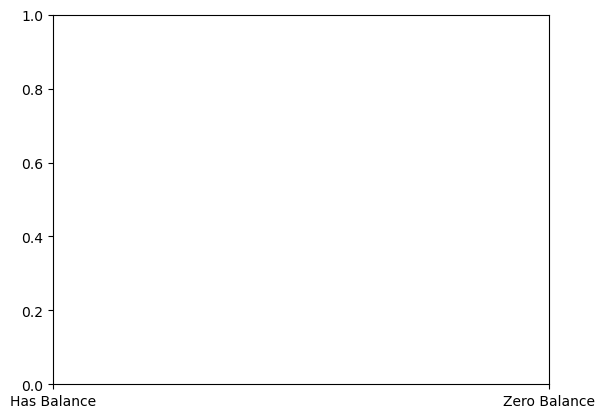

In [28]:
plt.xticks(
    ticks=[0, 1],
    labels=['Has Balance', 'Zero Balance'],
    rotation=0
)
plt.show()

products_number

In [29]:
df['products_number'].value_counts().sort_index()

products_number
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

In [30]:
product_churn = df.groupby('products_number')['churn'].mean()
product_churn

products_number
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: churn, dtype: float64

Product count shows a strong association with customer churn. Customers with two products have substantially lower churn (7.58%) than customers with one product (27.71%), while customers with three or four products show exceptionally high churn. However, the three- and four-product groups are relatively small, so these extreme churn rates should be interpreted cautiously.

Visualize it

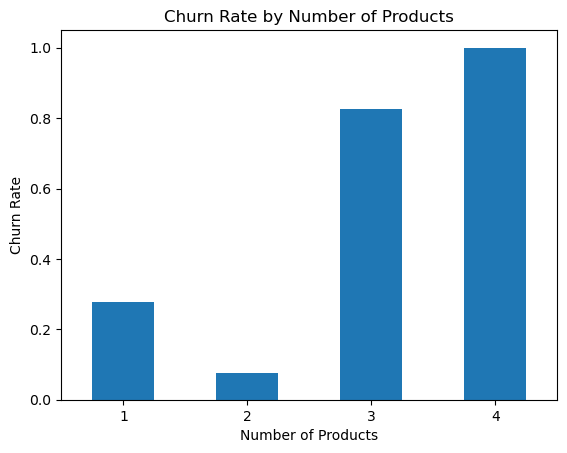

In [31]:
product_churn.plot(
    kind='bar',
    title='Churn Rate by Number of Products',
    xlabel='Number of Products',
    ylabel='Churn Rate'
)

plt.xticks(rotation=0)
plt.show()

In [32]:
pd.crosstab(
    df['products_number'],
    df['churn'],
    margins=True
)

churn,0,1,All
products_number,,,
1,3675,1409,5084
2,4242,348,4590
3,46,220,266
4,0,60,60
All,7963,2037,10000


active_member

In [33]:
df['active_member'].value_counts()

active_member
1    5151
0    4849
Name: count, dtype: int64

In [34]:
active_churn = df.groupby('active_member')['churn'].mean()
active_churn

active_member
0    0.268509
1    0.142691
Name: churn, dtype: float64

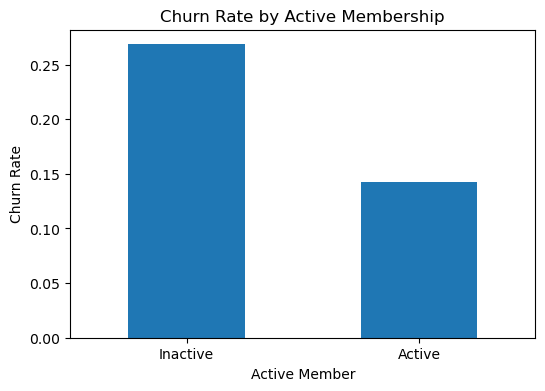

In [35]:
import matplotlib.pyplot as plt

active_churn.plot(
    kind='bar',
    figsize=(6, 4),
    title='Churn Rate by Active Membership'
)

plt.xlabel('Active Member')
plt.ylabel('Churn Rate')
plt.xticks(
    ticks=[0, 1],
    labels=['Inactive', 'Active'],
    rotation=0
)

plt.show()

credit_card

In [36]:
df['credit_card'].value_counts()

credit_card
1    7055
0    2945
Name: count, dtype: int64

In [37]:
credit_card_churn = df.groupby('credit_card')['churn'].mean()
credit_card_churn

credit_card
0    0.208149
1    0.201843
Name: churn, dtype: float64

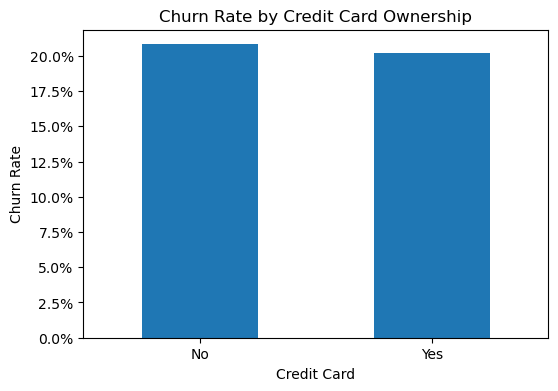

In [38]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

credit_card_churn.plot(
    kind='bar',
    figsize=(6, 4),
    title='Churn Rate by Credit Card Ownership'
)

plt.xlabel('Credit Card')
plt.ylabel('Churn Rate')
plt.xticks(
    ticks=[0, 1],
    labels=['No', 'Yes'],
    rotation=0
)

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.show()

In [39]:
df['estimated_salary'].describe()

count     10000.000000
mean     100090.239881
std       57510.492818
min          11.580000
25%       51002.110000
50%      100193.915000
75%      149388.247500
max      199992.480000
Name: estimated_salary, dtype: float64

In [40]:
bins = [0, 50000, 100000, 150000, 200000]
labels = ['0-50K', '50K-100K', '100K-150K', '150K-200K']

df['salary_group'] = pd.cut(
    df['estimated_salary'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df['salary_group'].value_counts().sort_index()

salary_group
0-50K        2453
50K-100K     2537
100K-150K    2555
150K-200K    2455
Name: count, dtype: int64

In [41]:
salary_churn = df.groupby('salary_group', observed=True)['churn'].mean()
salary_churn

salary_group
0-50K        0.199348
50K-100K     0.198660
100K-150K    0.202348
150K-200K    0.214664
Name: churn, dtype: float64

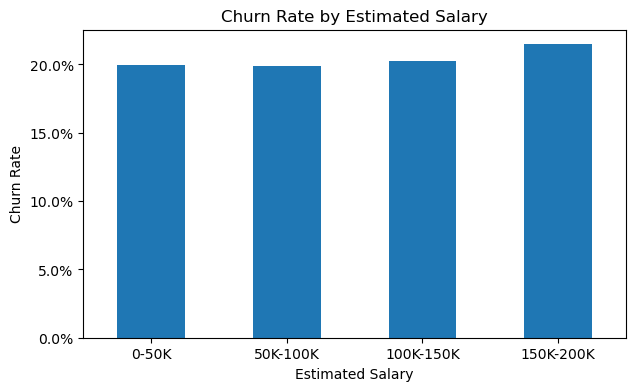

In [42]:
salary_churn.plot(
    kind='bar',
    figsize=(7, 4),
    title='Churn Rate by Estimated Salary'
)

plt.xlabel('Estimated Salary')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.show()

In [43]:
balance_bins = [0, 50000, 100000, 150000, 200000, 250000]
balance_labels = ['0-50K', '50K-100K', '100K-150K', '150K-200K', '200K+']

df['balance_group'] = pd.cut(
    df['balance'],
    bins=balance_bins,
    labels=balance_labels,
    include_lowest=True
)

df['balance_group'].value_counts().sort_index()

balance_group
0-50K        3692
50K-100K     1509
100K-150K    3830
150K-200K     935
200K+          33
Name: count, dtype: int64

In [44]:
balance_churn_group = df.groupby(
    'balance_group',
    observed=True
)['churn'].mean()

balance_churn_group

balance_group
0-50K        0.142470
50K-100K     0.198807
100K-150K    0.257702
150K-200K    0.219251
200K+        0.545455
Name: churn, dtype: float64

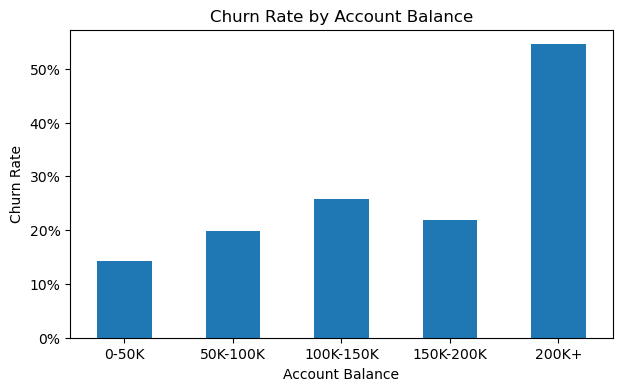

In [45]:
balance_churn_group.plot(
    kind='bar',
    figsize=(7, 4),
    title='Churn Rate by Account Balance'
)

plt.xlabel('Account Balance')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.show()

Age × Churn

In [46]:
age_churn_stats = df.groupby('churn')['age'].describe()
age_churn_stats

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,7963.0,37.408389,10.125363,18.0,31.0,36.0,41.0,92.0
1,2037.0,44.837997,9.761562,18.0,38.0,45.0,51.0,84.0


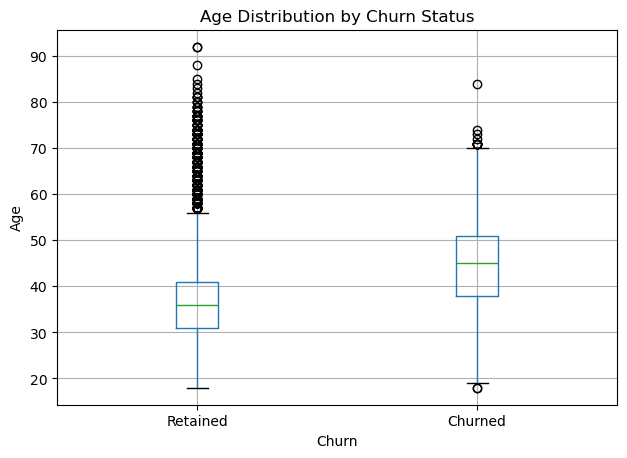

In [47]:
df.boxplot(
    column='age',
    by='churn',
    figsize=(7, 5)
)

plt.title('Age Distribution by Churn Status')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Age')

plt.xticks(
    ticks=[1, 2],
    labels=['Retained', 'Churned']
)

plt.show()

Age × Active Membership

In [48]:
age_active_churn = pd.crosstab(
    df['age_group'],
    df['active_member'],
    values=df['churn'],
    aggfunc='mean'
)

age_active_churn

active_member,0,1
age_group,,
18-25,0.111111,0.043344
26-35,0.108046,0.062708
36-45,0.242159,0.146287
46-55,0.636090,0.371517
56+,0.890995,0.179966


In [49]:
age_active_counts = pd.crosstab(
    df['age_group'],
    df['active_member']
)

age_active_counts

active_member,0,1
age_group,,
18-25,288,323
26-35,1740,1802
36-45,1945,1791
46-55,665,646
56+,211,589


In [50]:
product_active_churn = pd.crosstab(
    df['products_number'],
    df['active_member'],
    values=df['churn'],
    aggfunc='mean'
)

product_active_churn

active_member,0,1
products_number,,
1,0.366521,0.189231
2,0.098881,0.055601
3,0.882353,0.752212
4,1.000000,1.000000


In [51]:
numeric_cols = [
    'credit_score',
    'age',
    'tenure',
    'balance',
    'products_number',
    'estimated_salary',
    'active_member',
    'credit_card',
    'churn'
]

correlation_matrix = df[numeric_cols].corr()

correlation_matrix['churn'].sort_values(ascending=False)

churn               1.000000
age                 0.285323
balance             0.118533
estimated_salary    0.012097
credit_card        -0.007138
tenure             -0.014001
credit_score       -0.027094
products_number    -0.047820
active_member      -0.156128
Name: churn, dtype: float64

In [52]:
df['churn'].value_counts(normalize=True)

churn
0    0.7963
1    0.2037
Name: proportion, dtype: float64

In [53]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
customer_id           0
credit_score          0
country               0
gender                0
age                   0
tenure                0
balance               0
products_number       0
credit_card           0
active_member         0
estimated_salary      0
churn                 0
age_group             0
credit_score_group    0
salary_group          0
balance_group         1
dtype: int64

Duplicate rows:
0


In [54]:
balance_bins = [0, 50000, 100000, 150000, 200000, float('inf')]
balance_labels = ['0-50K', '50K-100K', '100K-150K', '150K-200K', '200K+']

df['balance_group'] = pd.cut(
    df['balance'],
    bins=balance_bins,
    labels=balance_labels,
    include_lowest=True
)

In [55]:
df['balance_group'].isnull().sum()

np.int64(0)

In [56]:
df.columns.tolist()

['customer_id',
 'credit_score',
 'country',
 'gender',
 'age',
 'tenure',
 'balance',
 'products_number',
 'credit_card',
 'active_member',
 'estimated_salary',
 'churn',
 'age_group',
 'credit_score_group',
 'salary_group',
 'balance_group']

In [57]:
model_df = df[
    [
        'credit_score',
        'country',
        'gender',
        'age',
        'tenure',
        'balance',
        'products_number',
        'credit_card',
        'active_member',
        'estimated_salary',
        'churn'
    ]
].copy()

model_df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [58]:
model_df.shape

(10000, 11)

In [59]:
X = model_df.drop('churn', axis=1)
y = model_df['churn']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 10)
y shape: (10000,)


In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 10)
X_test: (2000, 10)
y_train: (8000,)
y_test: (2000,)


In [61]:
print("Overall churn rate:", y.mean())
print("Training churn rate:", y_train.mean())
print("Testing churn rate:", y_test.mean())

Overall churn rate: 0.2037
Training churn rate: 0.20375
Testing churn rate: 0.2035


In [62]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = ['country', 'gender']

numerical_features = [
    'credit_score',
    'age',
    'tenure',
    'balance',
    'products_number',
    'credit_card',
    'active_member',
    'estimated_salary'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['country', 'gender']
Numerical features: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']


In [63]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [64]:
y_pred = logistic_model.predict(X_test)
y_pred_proba = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

Predictions generated successfully.
Number of predictions: 2000


In [65]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Accuracy:  0.8080
Precision: 0.5891
Recall:    0.1867
F1 Score:  0.2836
ROC-AUC:   0.7748


In [66]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1540   53]
 [ 331   76]]


In [67]:
print("Minimum probability:", y_pred_proba.min())
print("Maximum probability:", y_pred_proba.max())
print("Mean probability:", y_pred_proba.mean())

Minimum probability: 0.011708703608525712
Maximum probability: 0.860278698320512
Mean probability: 0.2030477896377402


In [68]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.50, 0.40, 0.30, 0.25, 0.20, 0.15, 0.10]

for threshold in thresholds:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.50 | Precision: 0.589 | Recall: 0.187 | F1: 0.284
Threshold: 0.40 | Precision: 0.531 | Recall: 0.312 | F1: 0.393
Threshold: 0.30 | Precision: 0.486 | Recall: 0.518 | F1: 0.502
Threshold: 0.25 | Precision: 0.431 | Recall: 0.602 | F1: 0.503
Threshold: 0.20 | Precision: 0.376 | Recall: 0.720 | F1: 0.494
Threshold: 0.15 | Precision: 0.328 | Recall: 0.838 | F1: 0.471
Threshold: 0.10 | Precision: 0.267 | Recall: 0.904 | F1: 0.412


In [69]:
threshold = 0.25

y_pred_025 = (y_pred_proba >= threshold).astype(int)

print("Predicted churners:", y_pred_025.sum())
print("Actual churners:", y_test.sum())

Predicted churners: 568
Actual churners: 407


In [70]:
from sklearn.metrics import confusion_matrix, classification_report

cm_025 = confusion_matrix(y_test, y_pred_025)

print("Confusion Matrix:")
print(cm_025)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_025,
    target_names=['Retained', 'Churned']
))

Confusion Matrix:
[[1270  323]
 [ 162  245]]

Classification Report:
              precision    recall  f1-score   support

    Retained       0.89      0.80      0.84      1593
     Churned       0.43      0.60      0.50       407

    accuracy                           0.76      2000
   macro avg       0.66      0.70      0.67      2000
weighted avg       0.79      0.76      0.77      2000



In [71]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight='balanced',
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [72]:
y_pred_rf = random_forest_model.predict(X_test)
y_pred_proba_rf = random_forest_model.predict_proba(X_test)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1 Score:  {f1_rf:.4f}")
print(f"ROC-AUC:   {roc_auc_rf:.4f}")

Accuracy:  0.8590
Precision: 0.7660
Recall:    0.4423
F1 Score:  0.5607
ROC-AUC:   0.8532


In [73]:
thresholds = [0.50, 0.40, 0.30, 0.25, 0.20, 0.15, 0.10]

for threshold in thresholds:
    y_pred_threshold_rf = (y_pred_proba_rf >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold_rf)
    recall = recall_score(y_test, y_pred_threshold_rf)
    f1 = f1_score(y_test, y_pred_threshold_rf)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.50 | Precision: 0.765 | Recall: 0.447 | F1: 0.564
Threshold: 0.40 | Precision: 0.663 | Recall: 0.536 | F1: 0.592
Threshold: 0.30 | Precision: 0.568 | Recall: 0.627 | F1: 0.596
Threshold: 0.25 | Precision: 0.526 | Recall: 0.720 | F1: 0.608
Threshold: 0.20 | Precision: 0.462 | Recall: 0.774 | F1: 0.579
Threshold: 0.15 | Precision: 0.398 | Recall: 0.843 | F1: 0.541
Threshold: 0.10 | Precision: 0.331 | Recall: 0.894 | F1: 0.483


In [74]:
rf_classifier = random_forest_model.named_steps['classifier']
rf_preprocessor = random_forest_model.named_steps['preprocessor']

feature_names = rf_preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_classifier.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance.head(15)

,feature,importance
1,num__age,0.251993
3,num__balance,0.139913
7,num__estimated_salary,0.139280
0,num__credit_score,0.134351
4,num__products_number,0.127067
2,num__tenure,0.082571
6,num__active_member,0.036328
9,cat__country_Germany,0.026267
5,num__credit_card,0.018291
8,cat__country_France,0.012533


In [75]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    random_forest_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc',
    n_jobs=-1
)

permutation_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values(
    'importance_mean',
    ascending=False
)

permutation_df

,feature,importance_mean,importance_std
3,age,0.122818,0.006244
6,products_number,0.116264,0.009529
5,balance,0.040483,0.006918
8,active_member,0.029982,0.003282
1,country,0.027030,0.002466
2,gender,0.008531,0.004470
4,tenure,0.001991,0.002747
9,estimated_salary,0.001919,0.002909
0,credit_score,0.001393,0.001744
7,credit_card,-0.000031,0.001551


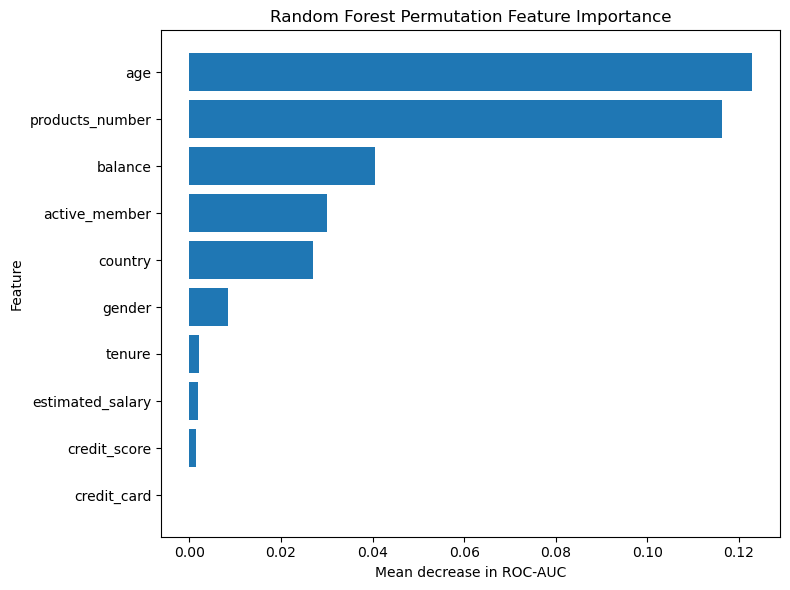

In [76]:
import matplotlib.pyplot as plt

plot_df = permutation_df.sort_values(
    'importance_mean',
    ascending=True
)

plt.figure(figsize=(8, 6))

plt.barh(
    plot_df['feature'],
    plot_df['importance_mean']
)

plt.xlabel('Mean decrease in ROC-AUC')
plt.ylabel('Feature')
plt.title('Random Forest Permutation Feature Importance')

plt.tight_layout()
plt.show()

In [77]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

logistic_cv = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc'
)

rf_cv = cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc'
)

print("Logistic Regression CV ROC-AUC:")
print(logistic_cv)
print("Mean:", logistic_cv.mean())
print("Std:", logistic_cv.std())

print("\nRandom Forest CV ROC-AUC:")
print(rf_cv)
print("Mean:", rf_cv.mean())
print("Std:", rf_cv.std())

Logistic Regression CV ROC-AUC:
[0.75727625 0.78135143 0.78695428 0.73143859 0.75687897]
Mean: 0.7627799019560632
Std: 0.01988311542318307

Random Forest CV ROC-AUC:
[0.85175309 0.86445402 0.86068467 0.82634883 0.84790068]
Mean: 0.8502282555306218
Std: 0.013339256118667825


In [81]:
from sklearn.model_selection import RandomizedSearchCV

rf_param_grid = {
    'classifier__n_estimators': [200, 300, 500],
    'classifier__max_depth': [None, 5, 10, 15, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__class_weight': ['balanced', 'balanced_subsample']
}

rf_search = RandomizedSearchCV(
    estimator=random_forest_model,
    param_distributions=rf_param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['credit_score',
                                                                                'age',
                                                                                'tenure',
                                                                                'balance',
                                                                                'products_number',
                                                                                'credit_card',
                                                                                'active_member',
                                                                                'estimated_salary']),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['country',
                                                                                'gende...
                   n_iter=20, n_jobs=-1,
                   param_distributions={'classifier__class_weight': ['balanced',
                                                                     'balanced_subsample'],
                                        'classifier__max_depth': [None, 5, 10,
                                                                  15, 20],
                                        'classifier__max_features': ['sqrt',
                                                                     'log2'],
                                        'classifier__min_samples_leaf': [1, 2,
                                                                         4],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'classifier__n_estimators': [200, 300,
                                                                     500]},
                   random_state=42, scoring='roc_auc', verbose=1)

In [82]:
print("Best CV ROC-AUC:", rf_search.best_score_)

print("\nBest Parameters:")
print(rf_search.best_params_)

Best CV ROC-AUC: 0.8574664599204475

Best Parameters:
{'classifier__n_estimators': 500, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 10, 'classifier__class_weight': 'balanced_subsample'}


In [83]:
best_rf = rf_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)
y_pred_proba_tuned = best_rf.predict_proba(X_test)[:, 1]

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Tuned Random Forest Test Performance")
print("------------------------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall   :", recall_score(y_test, y_pred_tuned))
print("F1 Score :", f1_score(y_test, y_pred_tuned))
print("ROC-AUC  :", roc_auc_score(y_test, y_pred_proba_tuned))

Tuned Random Forest Test Performance
------------------------------------
Accuracy : 0.839
Precision: 0.5963718820861678
Recall   : 0.6461916461916462
F1 Score : 0.6202830188679245
ROC-AUC  : 0.8597904530107919


[[1415  178]
 [ 144  263]]


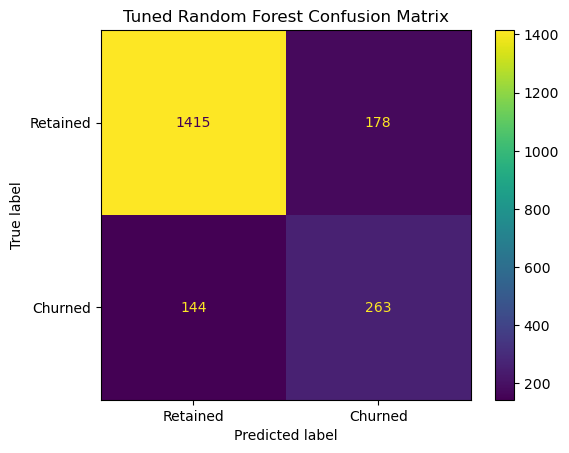

In [84]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_tuned)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Retained', 'Churned']
)

disp.plot()
plt.title('Tuned Random Forest Confusion Matrix')
plt.show()

In [86]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.50, 0.40, 0.30, 0.25, 0.20, 0.15]

for threshold in thresholds:
    y_pred_threshold = (y_pred_proba_tuned >= threshold).astype(int)

    print(f"Threshold: {threshold}")
    print(f"Precision: {precision_score(y_test, y_pred_threshold):.3f}")
    print(f"Recall:    {recall_score(y_test, y_pred_threshold):.3f}")
    print(f"F1 Score:  {f1_score(y_test, y_pred_threshold):.3f}")
    print()

Threshold: 0.5
Precision: 0.596
Recall:    0.646
F1 Score:  0.620

Threshold: 0.4
Precision: 0.494
Recall:    0.759
F1 Score:  0.599

Threshold: 0.3
Precision: 0.387
Recall:    0.857
F1 Score:  0.534

Threshold: 0.25
Precision: 0.338
Recall:    0.902
F1 Score:  0.492

Threshold: 0.2
Precision: 0.297
Recall:    0.939
F1 Score:  0.451

Threshold: 0.15
Precision: 0.262
Recall:    0.973
F1 Score:  0.412



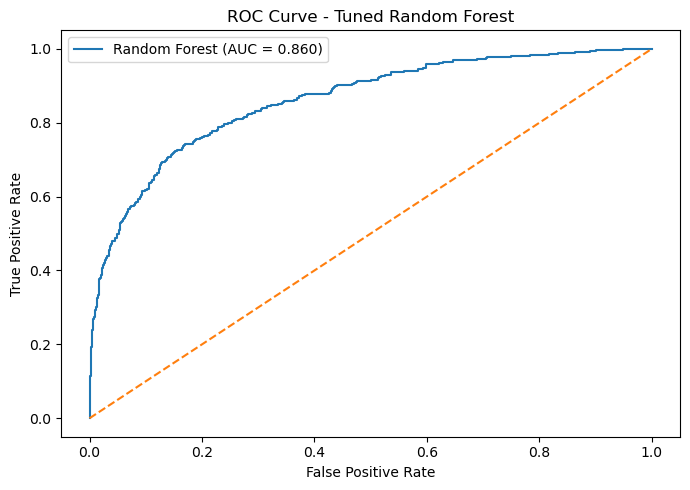

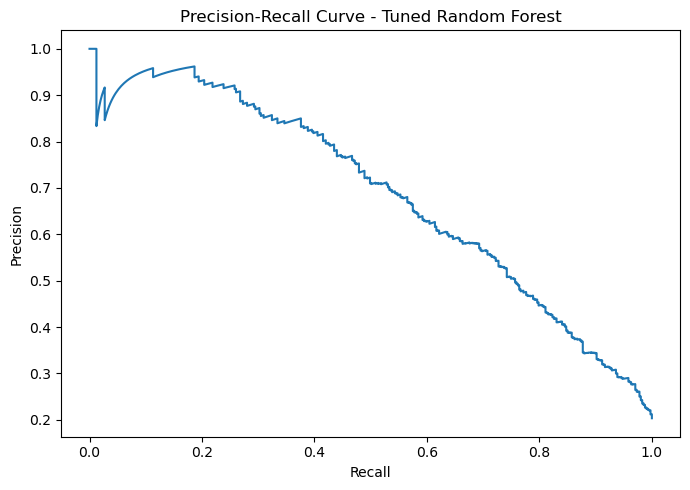

In [87]:
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    auc
)
import matplotlib.pyplot as plt

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_tuned)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(
    y_test,
    y_pred_proba_tuned
)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Tuned Random Forest')
plt.tight_layout()
plt.show()

In [88]:
# Get feature names after preprocessing
feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()

# Get feature importance
importances = best_rf.named_steps['classifier'].feature_importances_

# Create dataframe
final_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

final_importance_df.head(15)

,feature,importance
1,num__age,0.313108
4,num__products_number,0.197052
3,num__balance,0.117158
7,num__estimated_salary,0.084332
0,num__credit_score,0.081862
6,num__active_member,0.051890
2,num__tenure,0.048363
9,cat__country_Germany,0.041990
8,cat__country_France,0.014953
12,cat__gender_Male,0.014051


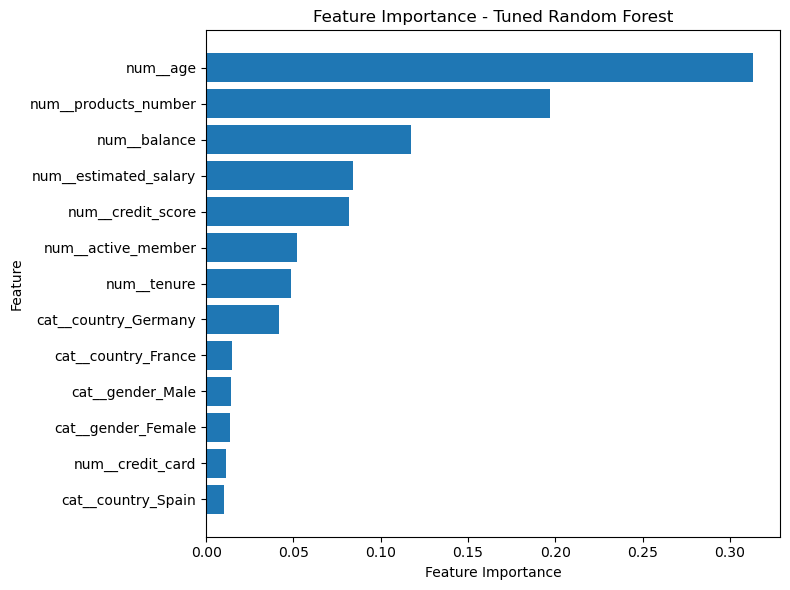

In [89]:
import matplotlib.pyplot as plt

plot_df = final_importance_df.sort_values(
    'importance',
    ascending=True
)

plt.figure(figsize=(8, 6))

plt.barh(
    plot_df['feature'],
    plot_df['importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance - Tuned Random Forest')

plt.tight_layout()
plt.show()